# Vehicle Counter — Design

---

## What Are We Building?

A system that watches a road from a fixed camera and **automatically counts vehicles** passing through a line.

```
Fixed Camera
     |
     v
  [Background Subtraction]   <- separate moving vehicles from road
     |
     v
  [Contour Detection]        <- find the shape/position of each vehicle
     |
     v
  [Centroid Tracking]        <- follow each vehicle across frames
     |
     v
  [Kalman Filter]            <- smooth noisy positions and predict movement
     |
     v
  [Counting Line]            <- count whenever a track crosses the line
```

## Why Is This Hard?

- Vehicles overlap each other
- Detection can fail for a few frames (occlusion)
- Shadows and light changes cause false detections
- Multiple vehicles may appear or disappear at the same time

## Topics We Will Cover:
1. Background Subtraction (recap + tuning for roads)
2. Contour Detection and Vehicle Blobs
3. Centroid Tracking (assign IDs and follow vehicles)
4. Kalman Filter (smooth noisy positions, predict gaps)
5. Counting Line Logic
6. Complete Pipeline (all combined)
7. What I Learned

---
# Part 1: Background Subtraction for Road Scenes

## Recap

Background subtraction builds a model of the empty road.
Anything that looks different from that model is marked as foreground — a moving vehicle.

## Why Road Scenes Are Tricky

- **Shadows** move with vehicles and look like extra blobs
- **Day/night** transitions slowly change the background brightness
- **Wet roads** create reflections
- **Stationary vehicles** (red light) slowly get absorbed into the background

## MOG2 Settings for Roads

```python
bg = cv2.createBackgroundSubtractorMOG2(
    history=500,          # 500 frames to build background model
                          # more frames = slower to adapt = better for slow changes
    varThreshold=60,      # higher threshold = less sensitive = fewer false positives
                          # good for roads with slight camera shake
    detectShadows=True    # mark shadows gray (127) so we can remove them
)
```

## Post-processing the Mask

```python
# 1. Remove shadows (keep only bright white = definite foreground)
_, fg = cv2.threshold(raw_mask, 200, 255, cv2.THRESH_BINARY)

# 2. Morphological cleaning
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)  # remove noise specks
fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)  # fill holes in vehicles
fg = cv2.dilate(fg, kernel, iterations=3)            # grow blobs (merge car parts)
```

The dilation step is especially important for vehicles because a car has windows, lights,
and gaps that produce separate blobs. Dilation merges them into one big blob.

Training on 20 empty-road frames...


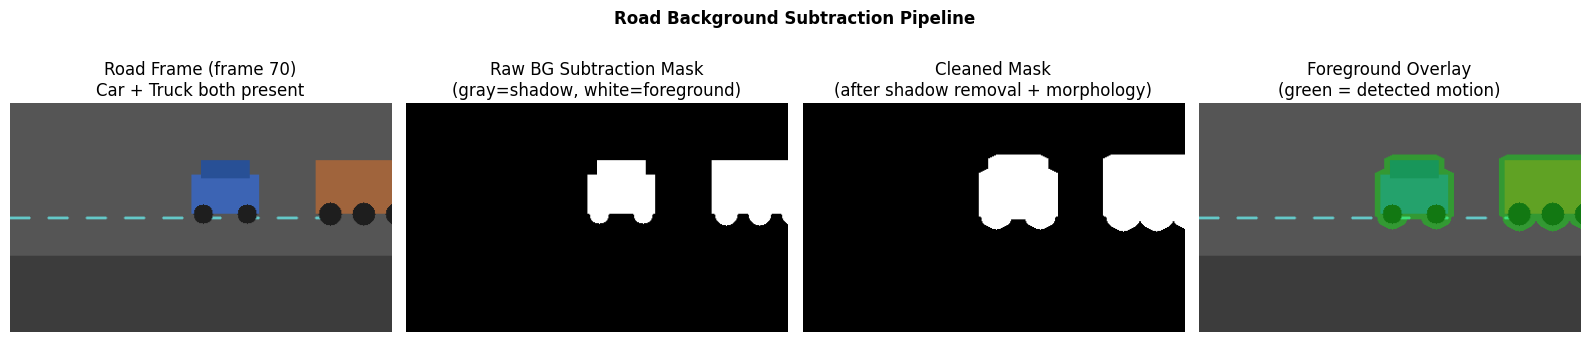

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Simulate a road scene with vehicles ───────────────────────────────────

def make_road_frame(idx, h=240, w=400):
    """
    Synthetic road scene:
    - Gray road background
    - Dashed center line
    - A car moving left to right
    - A truck moving right to left
    """
    frame = np.ones((h, w, 3), dtype=np.uint8) * 85     # road surface
    frame[160:h, :] = (60, 60, 60)                       # sidewalk

    # Dashed center line
    for x in range(0, w, 40):
        cv2.line(frame, (x, 120), (x+20, 120), (200, 200, 100), 2)

    # Car: moves left to right, present frames 20-100
    if 20 <= idx < 100:
        x = -60 + (idx - 20) * 5
        cv2.rectangle(frame, (x, 75), (x+70, 115), (180, 100, 60), -1)   # body
        cv2.rectangle(frame, (x+10, 60), (x+60, 78), (150, 80, 40), -1)  # roof
        cv2.circle(frame, (x+12, 116), 10, (30, 30, 30), -1)             # wheel L
        cv2.circle(frame, (x+58, 116), 10, (30, 30, 30), -1)             # wheel R

    # Truck: moves right to left, present frames 50-130
    if 50 <= idx < 130:
        x = w + 20 - (idx - 50) * 5
        cv2.rectangle(frame, (x, 60), (x+100, 115), (60, 100, 160), -1)  # body
        cv2.rectangle(frame, (x+80, 70), (x+100, 115), (80, 120, 180), -1) # cab
        cv2.circle(frame, (x+15,  116), 12, (30, 30, 30), -1)
        cv2.circle(frame, (x+50,  116), 12, (30, 30, 30), -1)
        cv2.circle(frame, (x+85,  116), 12, (30, 30, 30), -1)

    return frame

# Train background model
bg = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=50, detectShadows=True)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

print('Training on 20 empty-road frames...')
for i in range(20):
    bg.apply(make_road_frame(0))   # frame 0 = empty road

# Show detection at a frame where both vehicles are present
test_frame = make_road_frame(70)
raw_mask   = bg.apply(test_frame)

# Clean the mask
_, fg = cv2.threshold(raw_mask, 200, 255, cv2.THRESH_BINARY)
fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)
fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)
fg = cv2.dilate(fg, kernel, iterations=3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Road Frame (frame 70)\nCar + Truck both present')
axes[1].imshow(raw_mask, cmap='gray')
axes[1].set_title('Raw BG Subtraction Mask\n(gray=shadow, white=foreground)')
axes[2].imshow(fg, cmap='gray')
axes[2].set_title('Cleaned Mask\n(after shadow removal + morphology)')
axes[3].imshow(cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB))
# overlay the mask
overlay = test_frame.copy()
overlay[fg > 0] = [0, 255, 0]
blended = cv2.addWeighted(test_frame, 0.6, overlay, 0.4, 0)
axes[3].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
axes[3].set_title('Foreground Overlay\n(green = detected motion)')
for ax in axes: ax.axis('off')
plt.suptitle('Road Background Subtraction Pipeline', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('road_bg_subtraction.png', dpi=100)
plt.show()

---
# Part 2: Contour Detection — Finding Each Vehicle

## From Mask to Vehicle Blobs

After cleaning the foreground mask, we use contour detection to find each vehicle.
For a vehicle counter we care about:

1. **Area** — filter out tiny blobs (road noise, birds)
2. **Bounding box** — where is the vehicle?
3. **Centroid** — the single (x, y) point representing the vehicle's center

## Computing the Centroid

The centroid is the center of mass of the contour shape.
OpenCV computes it using **image moments**:

$$M = \text{cv2.moments(contour)}$$

$$c_x = \frac{M_{10}}{M_{00}}, \quad c_y = \frac{M_{01}}{M_{00}}$$

Where:
- $M_{00}$ = total area of the contour
- $M_{10}$ = sum of all x positions weighted by pixel area
- $M_{01}$ = sum of all y positions weighted by pixel area

A simpler approximation (good enough for rectangluar vehicles):

$$c_x = x + w/2, \quad c_y = y + h/2$$

where (x, y, w, h) comes from `cv2.boundingRect()`.

## Minimum Area Threshold

For road vehicles a good starting threshold is:
- Min area: 1500 px² (filters birds, leaves, shadows)
- Max area: 80% of frame area (filters full-frame noise frames)

Vehicles detected: 2

#     Centroid (cx,cy)       Bounding Box (x,y,w,h)       Area
----------------------------------------------------------------------
1     (356, 91)               (314, 54, 86, 81)           6357 px^2
2     (225, 92)               (184, 54, 83, 79)           5570 px^2


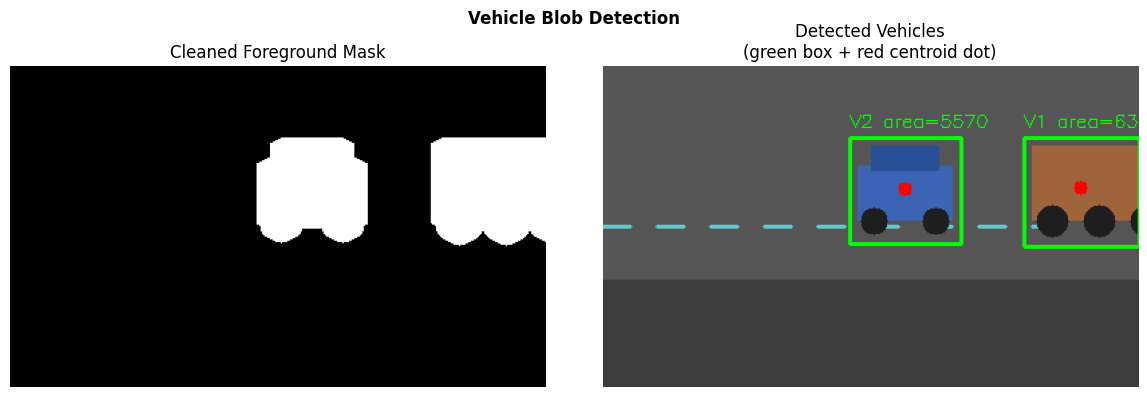


The centroid (red dot) is used in the next step to TRACK each vehicle.


In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt

# ── Vehicle detection from a cleaned mask ─────────────────────────────────

# Re-use the cleaned mask from Part 1
# (run Part 1 first, or recreate it here)

def get_vehicle_blobs(mask, min_area=800, max_area=50000):
    """
    Find vehicles in a cleaned foreground mask.
    Returns list of (centroid_x, centroid_y, bounding_rect, area).
    """
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    vehicles = []
    for cnt in cnts:
        area = cv2.contourArea(cnt)
        if not (min_area <= area <= max_area):
            continue

        # Bounding box
        x, y, w, h = cv2.boundingRect(cnt)

        # Centroid via moments (more accurate than box center)
        M = cv2.moments(cnt)
        if M['m00'] == 0:
            continue
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])

        vehicles.append((cx, cy, (x, y, w, h), area))
    return vehicles

# Use the mask from Part 1
vehicles = get_vehicle_blobs(fg, min_area=800)

display = test_frame.copy()
print(f'Vehicles detected: {len(vehicles)}')
print()
print(f'{"#":<5} {"Centroid (cx,cy)":<22} {"Bounding Box (x,y,w,h)":<28} {"Area"}')
print('-' * 70)
for i, (cx, cy, (x,y,w,h), area) in enumerate(vehicles):
    print(f'{i+1:<5} ({cx}, {cy}){"":<14} ({x}, {y}, {w}, {h}){"":<10} {area:.0f} px^2')
    cv2.rectangle(display, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.circle(display, (cx,cy), 5, (0,0,255), -1)
    cv2.putText(display, f'V{i+1} area={area:.0f}',
                (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,0), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(fg, cmap='gray')
axes[0].set_title('Cleaned Foreground Mask')
axes[1].imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
axes[1].set_title('Detected Vehicles\n(green box + red centroid dot)')
for ax in axes: ax.axis('off')
plt.suptitle('Vehicle Blob Detection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('vehicle_blobs.png', dpi=100)
plt.show()
print('\nThe centroid (red dot) is used in the next step to TRACK each vehicle.')

---
# Part 3: Centroid Tracking — Giving Each Vehicle an ID

## The Problem

Background subtraction gives us a list of detections each frame, but it does NOT
tell us which detection in frame 5 corresponds to which detection in frame 6.

```
Frame 5:  detections = [(120,90), (310,85)]       <- which is which?
Frame 6:  detections = [(132,90), (298,85)]       <- same vehicles, just moved
```

**Centroid Tracking** solves this by assigning each vehicle an ID and following it.

## The Algorithm

1. For each new frame, get the list of detected centroids
2. For each tracked object, find the CLOSEST new detection
3. If the closest detection is within a max distance → same vehicle, update position
4. If no detection is close enough → vehicle may be occluded, keep it for N frames
5. If a detection matches no existing track → new vehicle, assign a new ID
6. If a track has not been matched for M frames → remove it (vehicle left the scene)

## The Distance Check

We use Euclidean distance between old centroid and new centroid:

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

If $d < d_{max}$ (e.g., 80 pixels) we say it is the same vehicle.

This works because between two consecutive frames at 25 fps, a vehicle at 60 km/h
moves about 0.67 metres, which is roughly 20-40 pixels depending on camera zoom.

## Hungarian Algorithm (optional)

When there are many vehicles, simple nearest-neighbour matching can fail
(two vehicles might both want to match the same detection).
The **Hungarian algorithm** finds the globally optimal matching in one shot.
OpenCV's `dnn` module or `scipy.optimize.linear_sum_assignment` provides this.

In [3]:
import numpy as np
from collections import OrderedDict

# ── Centroid Tracker class ────────────────────────────────────────────────

class CentroidTracker:
    """
    Assigns stable IDs to moving objects across frames.

    How it works:
    - Keep a dictionary: {id: centroid}
    - Each frame: match new detections to existing tracks by nearest distance
    - Unmatched tracks survive for max_disappeared frames before removal
    - Unmatched detections get new IDs
    """

    def __init__(self, max_distance=80, max_disappeared=10):
        self.next_id       = 0            # ID counter
        self.objects       = OrderedDict() # {id: (cx, cy)}
        self.disappeared   = OrderedDict() # {id: frames_since_last_seen}
        self.max_distance  = max_distance  # pixel threshold to call it the same vehicle
        self.max_disappeared = max_disappeared

    def _register(self, cx, cy):
        """Add a brand-new vehicle."""
        self.objects[self.next_id] = (cx, cy)
        self.disappeared[self.next_id] = 0
        self.next_id += 1

    def _deregister(self, obj_id):
        """Remove a vehicle that has not been seen for too long."""
        del self.objects[obj_id]
        del self.disappeared[obj_id]

    def update(self, detections):
        """
        Main update step called every frame.
        detections: list of (cx, cy) tuples from contour detection
        Returns: {id: (cx, cy)} for all currently tracked vehicles
        """
        # Case 1: no detections this frame
        if len(detections) == 0:
            for obj_id in list(self.disappeared.keys()):
                self.disappeared[obj_id] += 1
                if self.disappeared[obj_id] > self.max_disappeared:
                    self._deregister(obj_id)
            return self.objects

        # Case 2: no tracks yet — register all detections as new
        if len(self.objects) == 0:
            for cx, cy in detections:
                self._register(cx, cy)
            return self.objects

        # Case 3: match existing tracks to new detections
        obj_ids    = list(self.objects.keys())
        obj_cents  = np.array(list(self.objects.values()))   # shape (N, 2)
        det_cents  = np.array(detections)                     # shape (M, 2)

        # Compute pairwise distances: D[i, j] = dist(track i, detection j)
        D = np.linalg.norm(
            obj_cents[:, np.newaxis, :] - det_cents[np.newaxis, :, :],
            axis=2
        )  # shape (N, M)

        # Greedy matching: sort by minimum distance
        rows = D.min(axis=1).argsort()   # track indices sorted by best match
        cols = D.argmin(axis=1)[rows]    # best matching detection for each track

        used_rows, used_cols = set(), set()

        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            if D[row, col] > self.max_distance:
                continue   # too far away — not the same vehicle

            obj_id = obj_ids[row]
            self.objects[obj_id] = (int(det_cents[col][0]), int(det_cents[col][1]))
            self.disappeared[obj_id] = 0
            used_rows.add(row)
            used_cols.add(col)

        # Unmatched tracks: increment disappeared counter
        for row in set(range(len(obj_ids))) - used_rows:
            obj_id = obj_ids[row]
            self.disappeared[obj_id] += 1
            if self.disappeared[obj_id] > self.max_disappeared:
                self._deregister(obj_id)

        # Unmatched detections: register as new vehicles
        for col in set(range(len(detections))) - used_cols:
            self._register(int(det_cents[col][0]), int(det_cents[col][1]))

        return self.objects


print('CentroidTracker defined.')
print('It will:')
print('  - Assign a stable ID to each vehicle')
print('  - Keep the ID even if detection fails for a few frames')
print('  - Remove the ID when the vehicle leaves the scene')

CentroidTracker defined.
It will:
  - Assign a stable ID to each vehicle
  - Keep the ID even if detection fails for a few frames
  - Remove the ID when the vehicle leaves the scene


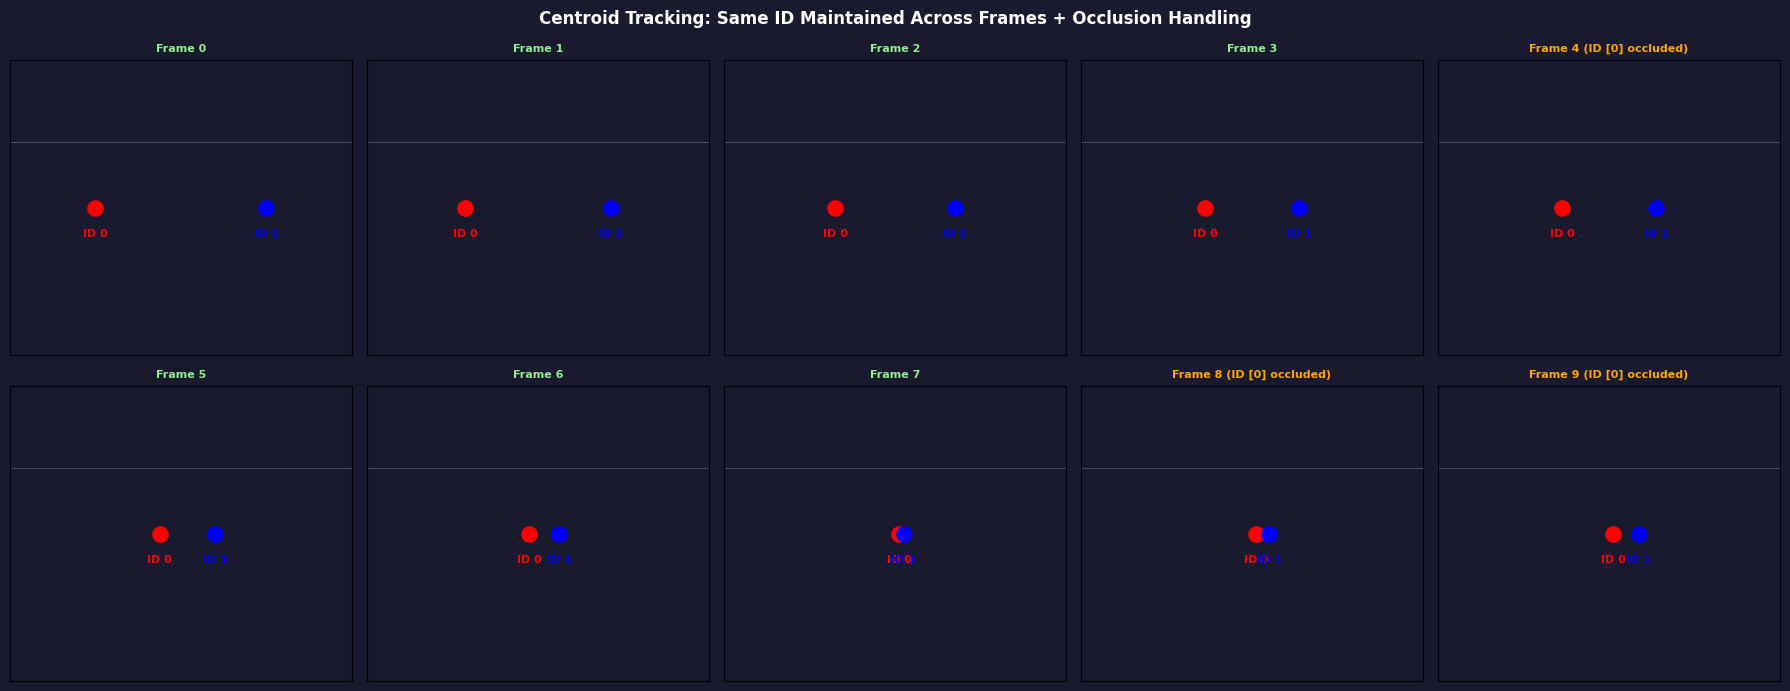

Notice: Frame 4 has only 1 detection but BOTH IDs survive.
Vehicle A keeps its ID (0) when it reappears in frame 5.
Without tracking, the reappeared vehicle would get a new ID — causing double counting!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Simulate 10 frames of tracking two vehicles ───────────────────────────

tracker = CentroidTracker(max_distance=80, max_disappeared=3)

# Simulated detections: two vehicles moving across the frame
# Vehicle A: moves right (x increases each frame)
# Vehicle B: moves left  (x decreases each frame)
# Frame 4: vehicle A disappears for 1 frame (occlusion), then reappears

sim_detections = [
    [(100, 90), (300, 90)],   # frame 0
    [(115, 90), (285, 90)],   # frame 1
    [(130, 90), (270, 90)],   # frame 2
    [(145, 90), (255, 90)],   # frame 3
    [(255, 90)],               # frame 4: vehicle A occluded (only B detected)
    [(175, 90), (240, 90)],   # frame 5: A reappears
    [(190, 90), (225, 90)],   # frame 6
    [(205, 90), (210, 90)],   # frame 7: nearly overlapping!
    [(220, 90)],               # frame 8: only B left
    [(235, 90)],               # frame 9
]

colors = {}
color_list = ['red', 'blue', 'green', 'orange', 'purple']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes_flat = axes.flatten()

for frame_idx, dets in enumerate(sim_detections):
    tracks = tracker.update(dets)

    ax = axes_flat[frame_idx]
    ax.set_xlim(0, 400); ax.set_ylim(0, 180)
    ax.set_facecolor('#1a1a2e')
    ax.axhline(130, color='white', lw=0.5, alpha=0.3)  # road line

    # Draw detections (white dots)
    for cx, cy in dets:
        ax.scatter(cx, cy, c='white', s=80, zorder=3, marker='+')

    # Draw tracks with ID and colored trail
    for obj_id, (cx, cy) in tracks.items():
        if obj_id not in colors:
            colors[obj_id] = color_list[obj_id % len(color_list)]
        c = colors[obj_id]
        ax.scatter(cx, cy, c=c, s=120, zorder=5)
        ax.annotate(f'ID {obj_id}', (cx, cy-18), color=c,
                    fontsize=8, fontweight='bold', ha='center')

    missing = [obj_id for obj_id, d in tracker.disappeared.items() if d > 0]
    title_color = 'orange' if missing else 'lightgreen'
    occl = f' (ID {missing} occluded)' if missing else ''
    ax.set_title(f'Frame {frame_idx}{occl}', fontsize=8,
                 color=title_color, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Centroid Tracking: Same ID Maintained Across Frames + Occlusion Handling',
             fontsize=12, fontweight='bold', color='white')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig('centroid_tracking.png', dpi=100, facecolor=fig.get_facecolor())
plt.show()

print('Notice: Frame 4 has only 1 detection but BOTH IDs survive.')
print('Vehicle A keeps its ID (0) when it reappears in frame 5.')
print('Without tracking, the reappeared vehicle would get a new ID — causing double counting!')

---
# Part 4: Kalman Filter — Smoothing and Predicting

## The Problem With Raw Centroids

Detection is noisy. Even for a vehicle driving in a perfectly straight line,
the detected centroid jumps around slightly each frame because:
- The vehicle's shadow changes shape
- The bounding box shifts due to contour noise
- Partial occlusion changes which pixels are detected

Also, detection can **fail completely** for 1-2 frames (tunnel, bridge shadow, overlap).
Without prediction, the track is lost.

## What a Kalman Filter Does

A Kalman filter is a mathematical tool that:
1. **Predicts** where the vehicle will be next frame based on its current speed
2. **Corrects** the prediction using the actual measurement (noisy centroid)
3. Gives a **smooth estimate** that is better than either raw input alone

```
               Predict step
State(t-1)  ──────────────────>  Predicted State(t)
                                          |
                               Measurement (noisy centroid)
                                          |
                                   Correct step
                                          |
                                          v
                                  Updated State(t)  <- smooth position
```

## State Vector

For a vehicle we track 4 values:

$$\text{state} = [x, y, v_x, v_y]^T$$

- x, y = current position
- $v_x$, $v_y$ = current velocity (pixels per frame)

## The Two Equations

**Predict** (where will it be next frame?):
$$\hat{x}_t = F \cdot x_{t-1}$$

$$F = \begin{bmatrix} 1 & 0 & 1 & 0 \\ 0 & 1 & 0 & 1 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

This says: new_x = old_x + vx, new_y = old_y + vy (constant velocity model)

**Correct** (blend prediction with measurement):
$$x_t = \hat{x}_t + K \cdot (z_t - H \cdot \hat{x}_t)$$

- $z_t$ = measured centroid (cx, cy)
- $H$ = measurement matrix (extracts x, y from state)
- $K$ = Kalman gain (how much to trust the measurement vs prediction)

If K is large: trust the measurement more (less smoothing)
If K is small: trust the prediction more (more smoothing)

OpenCV provides a ready-made `cv2.KalmanFilter` class.

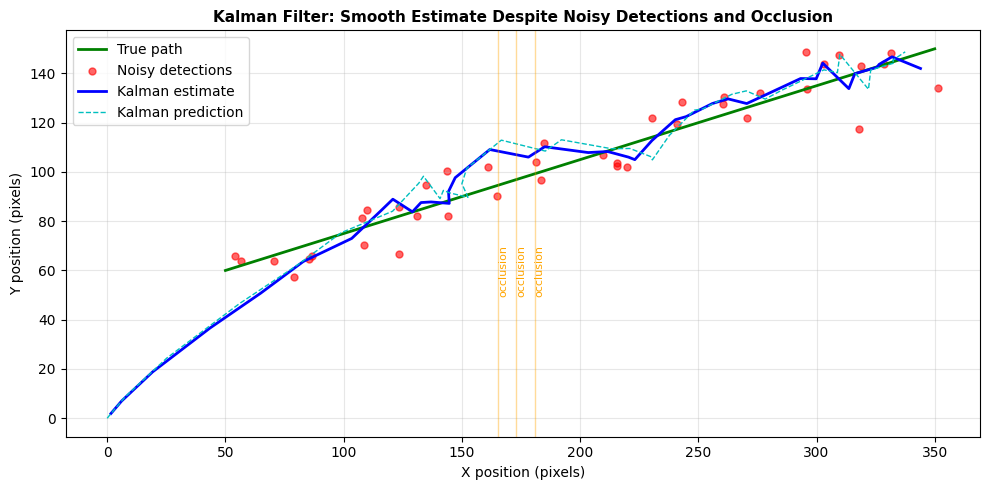

Green:  true vehicle path (perfect, unknown to the system)
Red:    noisy detections  (what the camera sees)
Blue:   Kalman estimate   (smooth, close to true path)
Orange: occlusion frames  (no detection, but Kalman predicts position anyway!)


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Build a Kalman Filter for one vehicle ────────────────────────────────

def make_kalman():
    """
    Create a Kalman filter for 2D vehicle tracking.
    State: [x, y, vx, vy]  (position + velocity)
    Measurement: [x, y]    (only position observed, not velocity)
    """
    kf = cv2.KalmanFilter(4, 2)   # 4 state variables, 2 measurements

    # Transition matrix F: x(t) = F * x(t-1)
    # New position = old position + velocity
    kf.transitionMatrix = np.array([
        [1, 0, 1, 0],   # x  = x  + vx
        [0, 1, 0, 1],   # y  = y  + vy
        [0, 0, 1, 0],   # vx = vx  (constant velocity)
        [0, 0, 0, 1],   # vy = vy
    ], dtype=np.float32)

    # Measurement matrix H: we only observe x and y
    kf.measurementMatrix = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
    ], dtype=np.float32)

    # Process noise Q: how much we think the velocity changes each frame
    # Higher Q = filter adapts faster to sudden maneuvers
    kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03

    # Measurement noise R: how noisy the centroid detection is
    # Higher R = filter trusts its own prediction more than the measurement
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1.0

    return kf


# ── Simulate a vehicle with noisy detections ──────────────────────────────
np.random.seed(42)
n_frames = 40

# True path: vehicle moves diagonally at constant speed
true_x = np.linspace(50, 350, n_frames)
true_y = np.linspace(60, 150, n_frames)

# Noisy measurements (detection jitter)
noise = 8
meas_x = true_x + np.random.randn(n_frames) * noise
meas_y = true_y + np.random.randn(n_frames) * noise

# Simulate 3 missing detections (occlusion)
missing = {15, 16, 17}

kf = make_kalman()
# Initialize state to first measurement
kf.statePre = np.array([[meas_x[0]], [meas_y[0]], [0.], [0.]], dtype=np.float32)

est_x, est_y, pred_x, pred_y = [], [], [], []

for i in range(n_frames):
    # Predict step (always done every frame)
    predicted = kf.predict()
    pred_x.append(predicted[0, 0])
    pred_y.append(predicted[1, 0])

    if i not in missing:
        # Correct step (only when detection available)
        measurement = np.array([[meas_x[i]], [meas_y[i]]], dtype=np.float32)
        corrected = kf.correct(measurement)
        est_x.append(corrected[0, 0])
        est_y.append(corrected[1, 0])
    else:
        # Use prediction only (no measurement this frame)
        est_x.append(predicted[0, 0])
        est_y.append(predicted[1, 0])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(true_x,  true_y,  'g-',  lw=2,   label='True path')
ax.scatter(meas_x, meas_y, c='red',   s=25, alpha=0.6, label='Noisy detections')
ax.plot(est_x,   est_y,   'b-',  lw=2,   label='Kalman estimate')
ax.plot(pred_x,  pred_y,  'c--', lw=1,   label='Kalman prediction')

# Mark missing frames
for m in missing:
    ax.axvline(true_x[m], color='orange', alpha=0.4, lw=1)
    ax.annotate('occlusion', (true_x[m], 50), fontsize=8, color='orange', rotation=90)

ax.set_xlabel('X position (pixels)')
ax.set_ylabel('Y position (pixels)')
ax.set_title('Kalman Filter: Smooth Estimate Despite Noisy Detections and Occlusion',
             fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kalman_tracking.png', dpi=100)
plt.show()

print('Green:  true vehicle path (perfect, unknown to the system)')
print('Red:    noisy detections  (what the camera sees)')
print('Blue:   Kalman estimate   (smooth, close to true path)')
print('Orange: occlusion frames  (no detection, but Kalman predicts position anyway!)')

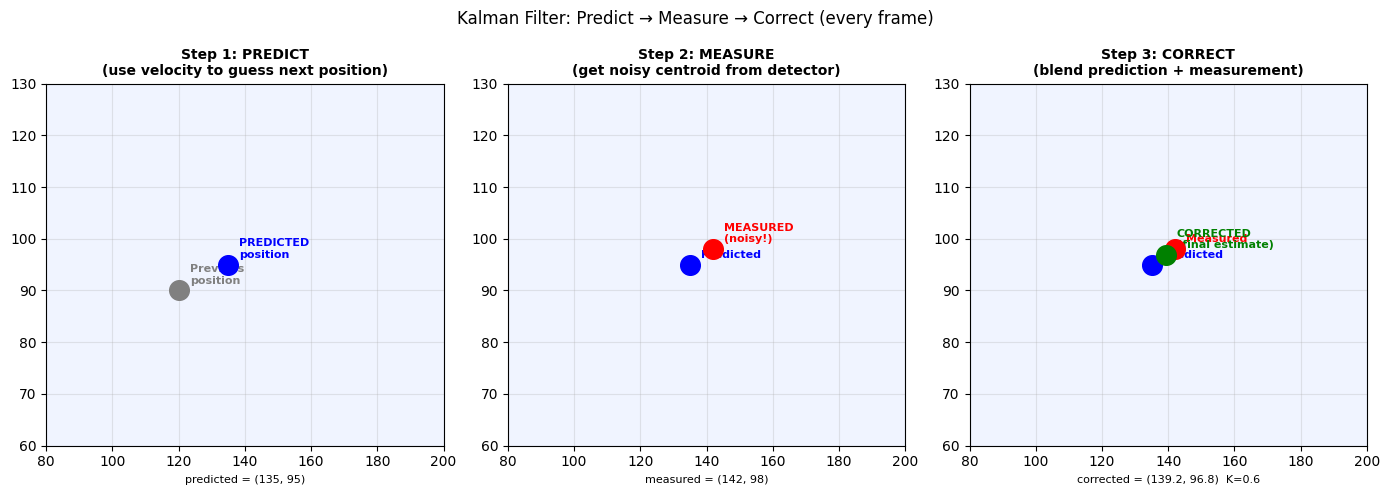

In [6]:
# ── Visualize Kalman Predict vs Correct steps ─────────────────────────────
# Show what happens at ONE frame: prediction, measurement, correction

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Positions
prev_pos   = np.array([120, 90])    # where vehicle was
velocity   = np.array([15, 5])      # estimated speed
predicted  = prev_pos + velocity    # where Kalman thinks it will be: (135, 95)
measured   = np.array([142, 98])    # noisy centroid from detector
kalman_gain = 0.6                   # how much to trust measurement (0=ignore, 1=full trust)
corrected  = predicted + kalman_gain * (measured - predicted)  # blend

for ax, title, pts, note in [
    (axes[0], 'Step 1: PREDICT\n(use velocity to guess next position)',
     [(prev_pos, 'Previous\nposition', 'gray'),
      (predicted, 'PREDICTED\nposition', 'blue')],
     f'predicted = ({predicted[0]}, {predicted[1]})'),
    (axes[1], 'Step 2: MEASURE\n(get noisy centroid from detector)',
     [(predicted, 'Predicted', 'blue'),
      (measured, 'MEASURED\n(noisy!)', 'red')],
     f'measured = ({measured[0]}, {measured[1]})'),
    (axes[2], 'Step 3: CORRECT\n(blend prediction + measurement)',
     [(predicted, 'Predicted', 'blue'),
      (measured, 'Measured', 'red'),
      (corrected, 'CORRECTED\n(final estimate)', 'green')],
     f'corrected = ({corrected[0]:.1f}, {corrected[1]:.1f})  K={kalman_gain}'),
]:
    ax.set_xlim(80, 200); ax.set_ylim(60, 130)
    ax.set_facecolor('#f0f4ff')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(note, fontsize=8)
    for pos, label, color in pts:
        ax.scatter(*pos, c=color, s=200, zorder=5)
        ax.annotate(label, pos, textcoords='offset points',
                    xytext=(8,5), fontsize=8, color=color, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Kalman Filter: Predict → Measure → Correct (every frame)', fontsize=12)
plt.tight_layout()
plt.savefig('kalman_steps.png', dpi=100)
plt.show()

---
# Part 5: Counting Line Logic

## The Idea

We draw a virtual counting line across the road.
Whenever a tracked vehicle's centroid **crosses** that line, we increment the count.

```
         Road (top view)
   ────────────────────────────
   →  car   →  car   →  car   ←  truck
   ────────────────────────────
        |  COUNTING LINE  |
   ────────────────────────────
```

## The Cross-Detection Logic

For each tracked vehicle, we store its **previous position** and **current position**.
We count it when it crosses the line:

For a **horizontal counting line** at y = LINE_Y:
```python
# Vehicle crossed from above to below:
if prev_y < LINE_Y and curr_y >= LINE_Y:
    count += 1

# Vehicle crossed from below to above (opposite direction):
if prev_y >= LINE_Y and curr_y < LINE_Y:
    count_reverse += 1
```

For a **vertical counting line** at x = LINE_X:
```python
if prev_x < LINE_X and curr_x >= LINE_X:
    count_left_to_right += 1
if prev_x >= LINE_X and curr_x < LINE_X:
    count_right_to_left += 1
```

## Why Not Just Check Current Position?

A vehicle might be detected ON the line two or three frames in a row.
If we just check `if cy == LINE_Y` we would count it multiple times.
Checking the **sign change** (crossed FROM one side TO the other) counts it exactly once.

## Handling Direction

By storing separate counters for each direction you can count:
- Vehicles going north vs south
- Vehicles entering vs leaving a zone
- Vehicles in each lane separately

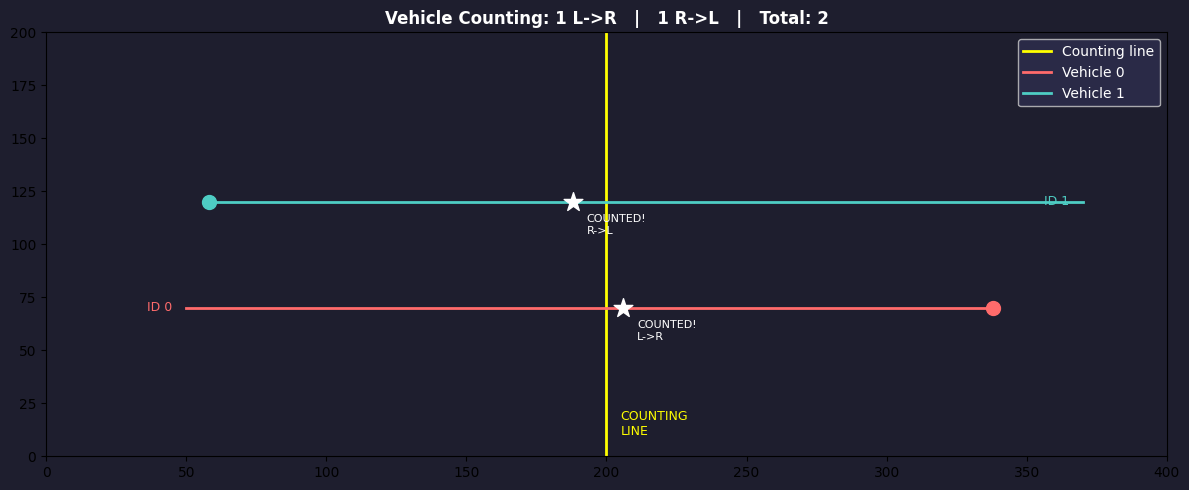

Stars = exact crossing events.
Left-to-right: 1  |  Right-to-left: 1


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Counting line demo ─────────────────────────────────────────────────────

LINE_X = 200   # vertical counting line at x=200 in a 400-wide frame
H, W = 200, 400

class VehicleCounter:
    """
    Counts vehicles crossing a vertical line.
    Tracks previous position of each ID to detect the crossing event.
    """
    def __init__(self, line_x):
        self.line_x    = line_x
        self.prev_pos  = {}   # {id: (prev_cx, prev_cy)}
        self.counted   = set() # IDs already counted (prevent double-count)
        self.count_lr  = 0    # left to right
        self.count_rl  = 0    # right to left

    def update(self, tracks):
        """tracks: {id: (cx, cy)} from CentroidTracker"""
        events = []
        for obj_id, (cx, cy) in tracks.items():
            if obj_id in self.prev_pos and obj_id not in self.counted:
                px, _ = self.prev_pos[obj_id]
                # Left to right crossing
                if px < self.line_x <= cx:
                    self.count_lr += 1
                    self.counted.add(obj_id)
                    events.append((obj_id, 'L->R', cx, cy))
                # Right to left crossing
                elif px >= self.line_x > cx:
                    self.count_rl += 1
                    self.counted.add(obj_id)
                    events.append((obj_id, 'R->L', cx, cy))
            self.prev_pos[obj_id] = (cx, cy)
        return events


# ── Simulate two vehicles crossing the line ───────────────────────────────
tracker = CentroidTracker(max_distance=80)
counter = VehicleCounter(line_x=LINE_X)

# Vehicle A: moves left to right, x goes 50->350 over 20 frames
# Vehicle B: moves right to left, x goes 370->50 over 20 frames
frames_data = []
for i in range(25):
    det_a = (50 + i*12, 70)
    det_b = (370 - i*13, 120)
    dets = [det_a]
    if det_b[0] > 0:
        dets.append(det_b)
    frames_data.append(dets)

track_history = {}   # {id: [(x,y), ...]}
all_events = []

for frame_idx, dets in enumerate(frames_data):
    tracks = tracker.update(dets)
    events = counter.update(tracks)
    all_events.extend([(frame_idx, *e) for e in events])
    for obj_id, pos in tracks.items():
        track_history.setdefault(obj_id, []).append(pos)

# Plot all tracks + counting events
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, W); ax.set_ylim(0, H)
ax.set_facecolor('#1e1e2e')

# Counting line
ax.axvline(LINE_X, color='yellow', lw=2, label='Counting line')
ax.text(LINE_X+5, 10, 'COUNTING\nLINE', color='yellow', fontsize=9)

colors_t = {}
clist = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#f8b739']
for obj_id, hist in track_history.items():
    colors_t[obj_id] = clist[obj_id % len(clist)]
    xs, ys = zip(*hist)
    ax.plot(xs, ys, '-', color=colors_t[obj_id], lw=2, label=f'Vehicle {obj_id}')
    ax.scatter(xs[-1], ys[-1], c=colors_t[obj_id], s=100, zorder=5)
    ax.text(xs[0]-5, ys[0], f'ID {obj_id}', color=colors_t[obj_id],
            fontsize=9, va='center', ha='right')

# Mark crossing events
for frame_idx, obj_id, direction, cx, cy in all_events:
    ax.scatter(cx, cy, c='white', s=200, marker='*', zorder=8)
    ax.text(cx+5, cy-15, f'COUNTED!\n{direction}', color='white', fontsize=8)

ax.set_title(f'Vehicle Counting: {counter.count_lr} L->R   |   {counter.count_rl} R->L   |   Total: {counter.count_lr + counter.count_rl}',
             fontsize=12, fontweight='bold', color='white')
ax.legend(loc='upper right', facecolor='#2e2e4e', labelcolor='white')
fig.patch.set_facecolor('#1e1e2e')
plt.tight_layout()
plt.savefig('counting_line.png', dpi=100, facecolor=fig.get_facecolor())
plt.show()

print('Stars = exact crossing events.')
print(f'Left-to-right: {counter.count_lr}  |  Right-to-left: {counter.count_rl}')

---
# Part 6: Complete Vehicle Counter Pipeline

Now we put all four components together:

```
BG Subtraction  ->  Contour Detection  ->  Centroid Tracking  ->  Kalman Filter  ->  Counting
```

The Kalman filter wraps each track — when detection is available it corrects,
when detection is missing it just predicts.

To run on a real video:
```python
run_vehicle_counter(source='road_video.mp4')
```

To run on a webcam:
```python
run_vehicle_counter(source=0)
```

In [8]:
import cv2, numpy as np
from collections import OrderedDict

# ── KalmanTracker: one Kalman filter per vehicle ──────────────────────────

class KalmanTracker:
    """
    Wraps cv2.KalmanFilter for a single vehicle.
    Maintains a smooth position estimate and velocity.
    """
    def __init__(self, cx, cy):
        self.kf = cv2.KalmanFilter(4, 2)
        self.kf.transitionMatrix  = np.array([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]], np.float32)
        self.kf.measurementMatrix = np.array([[1,0,0,0],[0,1,0,0]], np.float32)
        self.kf.processNoiseCov   = np.eye(4, dtype=np.float32) * 0.03
        self.kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 2.0
        self.kf.errorCovPost      = np.eye(4, dtype=np.float32)
        self.kf.statePost         = np.array([[cx],[cy],[0],[0]], dtype=np.float32)
        self.disappeared = 0
        self.history     = [(cx, cy)]

    def predict(self):
        """Predict next position."""
        pred = self.kf.predict()
        return int(pred[0,0]), int(pred[1,0])

    def correct(self, cx, cy):
        """Update with actual measurement."""
        m = np.array([[cx],[cy]], dtype=np.float32)
        c = self.kf.correct(m)
        pos = (int(c[0,0]), int(c[1,0]))
        self.history.append(pos)
        return pos


# ── KalmanCentroidTracker: manages all vehicles ───────────────────────────

class KalmanCentroidTracker:
    """Like CentroidTracker but each track has its own Kalman filter."""

    def __init__(self, max_distance=80, max_disappeared=8):
        self.next_id        = 0
        self.trackers       = OrderedDict()  # {id: KalmanTracker}
        self.max_distance   = max_distance
        self.max_disappeared = max_disappeared

    def update(self, detections):
        """
        detections: list of (cx, cy)
        Returns: {id: (smooth_cx, smooth_cy)}
        """
        # Predict all existing tracks
        predicted = {oid: t.predict() for oid, t in self.trackers.items()}

        if len(detections) == 0:
            for oid in list(self.trackers):
                self.trackers[oid].disappeared += 1
                if self.trackers[oid].disappeared > self.max_disappeared:
                    del self.trackers[oid]
            return predicted

        det_arr = np.array(detections, dtype=float)

        if len(self.trackers) == 0:
            for cx, cy in detections:
                self.trackers[self.next_id] = KalmanTracker(cx, cy)
                self.next_id += 1
            return {oid: t.history[-1] for oid, t in self.trackers.items()}

        obj_ids   = list(predicted.keys())
        pred_arr  = np.array(list(predicted.values()), dtype=float)

        D = np.linalg.norm(pred_arr[:,None,:] - det_arr[None,:,:], axis=2)

        rows = D.min(axis=1).argsort()
        cols = D.argmin(axis=1)[rows]
        used_r, used_c = set(), set()

        result = {}
        for r, c in zip(rows, cols):
            if r in used_r or c in used_c:
                continue
            if D[r, c] > self.max_distance:
                continue
            oid = obj_ids[r]
            pos = self.trackers[oid].correct(*detections[c])
            self.trackers[oid].disappeared = 0
            result[oid] = pos
            used_r.add(r); used_c.add(c)

        for r in set(range(len(obj_ids))) - used_r:
            oid = obj_ids[r]
            self.trackers[oid].disappeared += 1
            if self.trackers[oid].disappeared > self.max_disappeared:
                del self.trackers[oid]
            else:
                result[oid] = predicted[oid]

        for c in set(range(len(detections))) - used_c:
            cx, cy = detections[c]
            self.trackers[self.next_id] = KalmanTracker(cx, cy)
            result[self.next_id] = (cx, cy)
            self.next_id += 1

        return result


print('KalmanCentroidTracker defined.')
print('Each tracked vehicle has its own Kalman filter.')
print('Even during occlusion, the system predicts position and maintains the count.')

KalmanCentroidTracker defined.
Each tracked vehicle has its own Kalman filter.
Even during occlusion, the system predicts position and maintains the count.


Running vehicle counter...


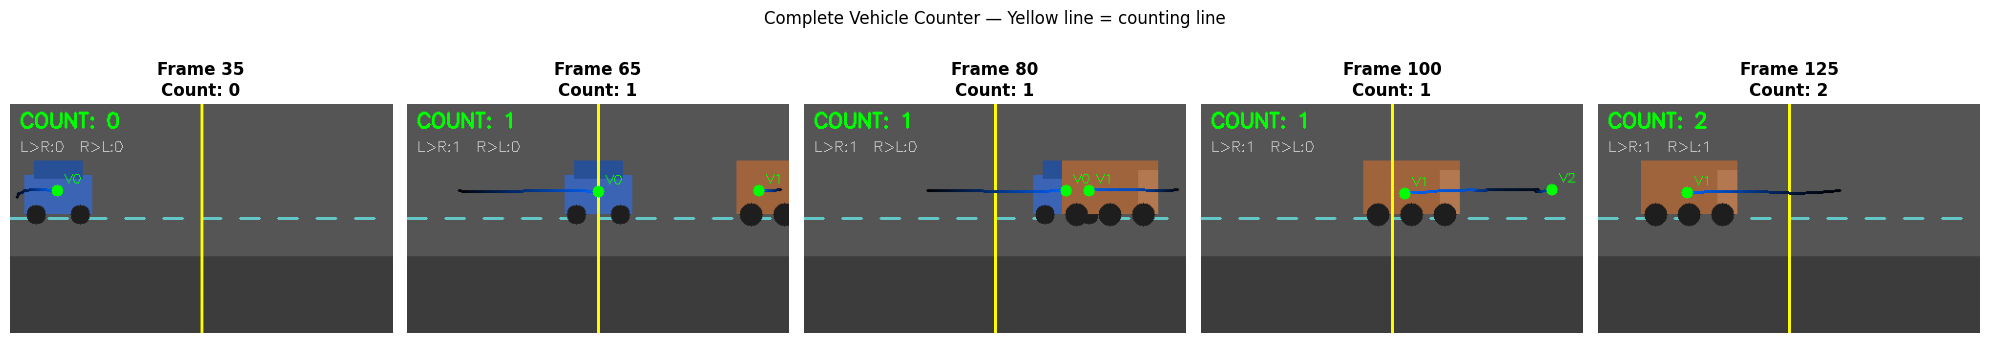

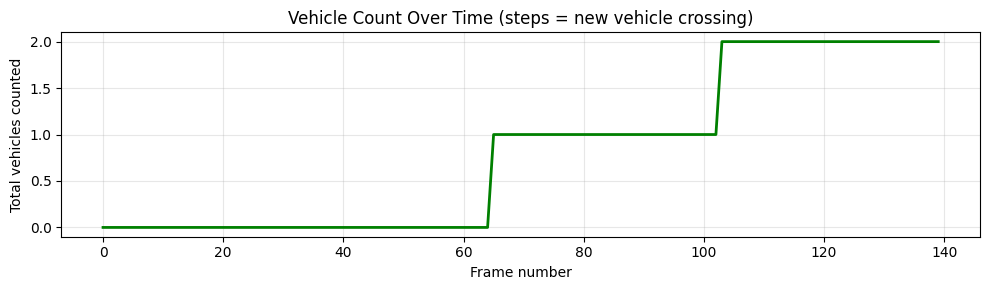

Final count: 1 L->R  +  1 R->L  =  2 total


In [9]:
import cv2, numpy as np, matplotlib.pyplot as plt

# ── Complete pipeline on synthetic road video ─────────────────────────────

# Configuration
H, W       = 240, 400
LINE_X     = W // 2          # vertical counting line in the middle
MIN_AREA   = 800
TOTAL_FRAMES = 140

# ── Initialize all components ─────────────────────────────────────────────
bg_sub   = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=50, detectShadows=True)
kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
tracker  = KalmanCentroidTracker(max_distance=80, max_disappeared=8)
counter  = VehicleCounter(line_x=LINE_X)

# ── Counters and history ──────────────────────────────────────────────────
track_trails  = {}   # {id: [(x,y)...]} for drawing trails
count_history = []   # total count per frame for plotting

# Train background model on 30 empty-road frames
for i in range(30):
    bg_sub.apply(make_road_frame(0))

print('Running vehicle counter...')
saved_frames = []

for frame_idx in range(TOTAL_FRAMES):
    frame = make_road_frame(frame_idx)

    # 1. Background subtraction
    raw  = bg_sub.apply(frame)
    _, fg = cv2.threshold(raw, 200, 255, cv2.THRESH_BINARY)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)
    fg = cv2.dilate(fg, kernel, iterations=3)

    # 2. Contour detection
    cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = []
    for cnt in cnts:
        if cv2.contourArea(cnt) < MIN_AREA:
            continue
        M = cv2.moments(cnt)
        if M['m00'] == 0: continue
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
        detections.append((cx, cy))

    # 3. Kalman tracking
    tracks = tracker.update(detections)

    # 4. Counting
    counter.update(tracks)

    # Update trails
    for oid, pos in tracks.items():
        track_trails.setdefault(oid, []).append(pos)
        if len(track_trails[oid]) > 30:  # keep last 30 positions
            track_trails[oid].pop(0)

    total = counter.count_lr + counter.count_rl
    count_history.append(total)

    # Annotate display frame
    display = frame.copy()
    cv2.line(display, (LINE_X, 0), (LINE_X, H), (0, 255, 255), 2)
    cv2.putText(display, f'COUNT: {total}', (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
    cv2.putText(display, f'L>R:{counter.count_lr}  R>L:{counter.count_rl}',
                (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

    for oid, pos in tracks.items():
        trail = track_trails.get(oid, [])
        for j in range(1, len(trail)):
            alpha = j / len(trail)
            color = (int(255*alpha), int(100*alpha), 0)
            cv2.line(display, trail[j-1], trail[j], color, 2)
        cv2.circle(display, pos, 6, (0,255,0), -1)
        cv2.putText(display, f'V{oid}', (pos[0]+8, pos[1]-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,0), 1)

    if frame_idx in [35, 65, 80, 100, 125]:
        saved_frames.append((frame_idx, display.copy(), total))

# ── Display selected frames ───────────────────────────────────────────────
n = len(saved_frames)
fig, axes = plt.subplots(1, n, figsize=(n*4, 4))
for ax, (idx, frm, cnt) in zip(axes, saved_frames):
    ax.imshow(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {idx}\nCount: {cnt}', fontweight='bold')
    ax.axis('off')
plt.suptitle('Complete Vehicle Counter — Yellow line = counting line', fontsize=12)
plt.tight_layout()
plt.savefig('vehicle_counter_demo.png', dpi=100)
plt.show()

# ── Count over time plot ──────────────────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.plot(count_history, 'g-', lw=2)
plt.xlabel('Frame number')
plt.ylabel('Total vehicles counted')
plt.title('Vehicle Count Over Time (steps = new vehicle crossing)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('count_over_time.png', dpi=100)
plt.show()

print(f'Final count: {counter.count_lr} L->R  +  {counter.count_rl} R->L  =  {counter.count_lr+counter.count_rl} total')

---
# Part 7: Run on a Real Video or Webcam

Change `VIDEO_SOURCE` to:
- `0` for webcam
- `'road.mp4'` for a video file

The counting line position `LINE_X` (vertical) or `LINE_Y` (horizontal) should be
placed where vehicles reliably pass one at a time.

Press **Q** to quit.

In [10]:
import cv2, numpy as np

# ── Configuration ─────────────────────────────────────────────────────────
VIDEO_SOURCE = 0           # 0 = webcam, or 'road.mp4'
LINE_X       = None        # vertical line  (set to e.g. 320 for 640-wide video)
LINE_Y       = 300         # horizontal line (set to None to use vertical instead)
MIN_AREA     = 1500        # px^2 — adjust for your camera zoom

def run_vehicle_counter(source=VIDEO_SOURCE):
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        print('ERROR: Cannot open source:', source)
        return

    fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    bg_sub  = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=60, detectShadows=True)
    kern    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    tracker = KalmanCentroidTracker(max_distance=80, max_disappeared=10)

    # Determine counting line
    use_x_line = LINE_X is not None
    line_pos   = LINE_X if use_x_line else LINE_Y

    prev_positions = {}   # {id: (cx, cy)}
    counted = set()
    count_fwd, count_bwd = 0, 0
    trails = {}
    frame_idx = 0

    print(f'Running on {source} ({fw}x{fh}). Press Q to quit.')

    while True:
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1

        # Background subtraction + cleanup
        raw = bg_sub.apply(frame)
        _, fg = cv2.threshold(raw, 200, 255, cv2.THRESH_BINARY)
        fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kern)
        fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kern)
        fg = cv2.dilate(fg, kern, iterations=2)

        # Contour detection
        cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        dets = []
        for cnt in cnts:
            if cv2.contourArea(cnt) < MIN_AREA: continue
            M = cv2.moments(cnt)
            if M['m00'] == 0: continue
            dets.append((int(M['m10']/M['m00']), int(M['m01']/M['m00'])))

        # Kalman tracking
        tracks = tracker.update(dets)

        # Counting
        for oid, (cx, cy) in tracks.items():
            if oid in prev_positions and oid not in counted:
                px, py = prev_positions[oid]
                if use_x_line:
                    if px < line_pos <= cx:  count_fwd += 1; counted.add(oid)
                    elif px >= line_pos > cx: count_bwd += 1; counted.add(oid)
                else:
                    if py < line_pos <= cy:  count_fwd += 1; counted.add(oid)
                    elif py >= line_pos > cy: count_bwd += 1; counted.add(oid)
            prev_positions[oid] = (cx, cy)
            trails.setdefault(oid, []).append((cx, cy))
            if len(trails[oid]) > 40: trails[oid].pop(0)

        # Draw
        display = frame.copy()
        if use_x_line:
            cv2.line(display, (line_pos,0), (line_pos,fh), (0,255,255), 2)
        else:
            cv2.line(display, (0,line_pos), (fw,line_pos), (0,255,255), 2)

        for oid, (cx, cy) in tracks.items():
            trail = trails.get(oid, [])
            for j in range(1, len(trail)):
                cv2.line(display, trail[j-1], trail[j], (0,140,255), 2)
            cv2.circle(display, (cx, cy), 6, (0,255,0), -1)
            cv2.putText(display, f'V{oid}', (cx+8, cy-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        total = count_fwd + count_bwd
        cv2.putText(display, f'TOTAL: {total}  (fwd:{count_fwd} bwd:{count_bwd})',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

        cv2.imshow('Vehicle Counter', display)
        cv2.imshow('FG Mask', fg)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

    cap.release()
    cv2.destroyAllWindows()
    print(f'Done. {frame_idx} frames. Total vehicles: {count_fwd+count_bwd}')


# run_vehicle_counter(source=0)

---
# Summary

## The Full Pipeline

| Step | Tool | Role |
|------|------|------|
| Background subtraction | `cv2.createBackgroundSubtractorMOG2()` | Separate moving vehicles from road |
| Mask cleaning | `morphologyEx OPEN + CLOSE + dilate` | Remove noise, merge car parts |
| Contour detection | `cv2.findContours` + `cv2.moments` | Find centroid of each vehicle |
| Centroid tracking | Custom nearest-neighbour matching | Assign stable IDs |
| Kalman filter | `cv2.KalmanFilter(4, 2)` | Smooth positions, predict during occlusion |
| Counting line | Sign-change crossing check | Count each vehicle exactly once |

## Key Parameters to Tune

```python
varThreshold = 60     # BG subtraction sensitivity (higher = less sensitive)
MIN_AREA     = 1500   # min blob size in pixels (filter out small noise)
max_distance = 80     # max pixels a vehicle can move per frame (tracking)
max_disappeared = 8   # how many frames before removing a lost track
processNoiseCov = 0.03  # Kalman: higher = adapts faster to speed changes
measurementNoiseCov = 2.0  # Kalman: higher = trusts prediction over detection
LINE_X or LINE_Y     # position of the counting line in pixels
```

## Quick Start

```python
# On a video file
run_vehicle_counter(source='road_video.mp4')

# On a webcam
run_vehicle_counter(source=0)
```

---
# What I Learned

I learned how to design a complete vehicle counting pipeline from scratch.

The first thing I learned is that background subtraction works well for road cameras because the road surface stays still while vehicles move. The MOG2 method builds a model of each pixel over time and flags anything that looks different as a moving object. On roads I need a higher threshold than normal to avoid triggering on shadows and slight camera vibration. I also need to dilate the foreground mask more than usual because a vehicle has windows and gaps that produce separate blobs, and dilation merges them into one big blob representing the whole car.

The next thing I learned is contour detection for vehicles. After cleaning the mask I find the contours and filter by area to remove bird and leaf noise. The important output of this step is the centroid, the single x y point that represents the center of each vehicle. I compute it using image moments, which give a more accurate center than just using the midpoint of the bounding box.

I learned about centroid tracking, which is the step that gives each vehicle a stable ID across many frames. The key insight is that between two consecutive frames a vehicle only moves a small number of pixels. So if I compute the Euclidean distance between each existing track and each new detection, the smallest distance is almost always the correct match. If no match is found within the maximum distance, the vehicle might be temporarily occluded, so I keep the track alive for several frames before deleting it. This prevents a vehicle that briefly disappears behind a truck from being counted twice when it reappears.

I learned about the Kalman filter, which solves two problems at once. First it smooths the noisy centroid positions that come from background subtraction jitter. Second it predicts where the vehicle will be even when the detector completely fails for a few frames. The filter keeps a state of four values: x position, y position, x velocity, and y velocity. Every frame it first predicts the new position using the current velocity estimate, then it corrects that prediction using the actual measurement if one is available. The Kalman gain controls how much to trust the measurement versus the prediction. This means during an occlusion the track keeps moving at its current estimated speed and does not jump around.

I learned the counting line trick. I place a virtual line across the road and check for each tracked vehicle whether it crossed from one side of the line to the other between the previous frame and the current frame. I check the sign change in position rather than just whether the vehicle is near the line, because a vehicle might be detected near the line for several frames and I only want to count it once. By keeping separate counters for each crossing direction I can count vehicles going north and south independently.

Overall I learned that a good counting system is built in layers. Each layer solves a specific problem: detection, noise removal, identity assignment, position smoothing, and crossing detection. Tuning the system means adjusting parameters at each layer separately until it works well for the specific camera and road conditions.